In [1]:
import os
import glob
import cv2
import numpy as np
import math

# =========================================================
#  SECTION A:
#    ПОЛЕЗНЫЕ ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
#    (генерация шума, бинаризация, морфологические оп-ции,
#     вычисление морфологических индексов,
#     коэффициент Кендалла)
# =========================================================

def ensure_dir(directory):
    """
    Создает папку, если ее нет.
    """
    if not os.path.exists(directory):
        os.makedirs(directory)

def add_gaussian_noise(img_gray, sigma=20):
    """
    Генерация аддитивного гауссовского шума N(0, sigma^2) 
    и наложение на изображение, с усечением диапазона [0..255].

    Матем. с точки зрения:
      f'(x) = f(x) + ε(x),
      где ε(x) ~ N(0, sigma^2).
      После чего clamp(f'(x)) в [0..255].
    """
    # Преобразуем к float32 для суммирования
    float_img = img_gray.astype(np.float32)
    noise = np.random.normal(0, sigma, float_img.shape).astype(np.float32)
    noisy_img = float_img + noise
    noisy_img = np.clip(noisy_img, 0, 255)
    return noisy_img.astype(np.uint8)

def binarize_otsu(img_gray):
    """
    Глобальная бинаризация методом Оцу:
      T* = arg minVar(between)
    Возвращает бинарное изображение (0/255).
    """
    _, bin_img = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return bin_img

def morph_open_close(bin_img, ksize=3):
    """
    Типичная морфологическая очистка:
      - Операция "открытие" (erosion -> dilation), убирает мелкие белые шумовые объекты.
      - Операция "закрытие" (dilation -> erosion), восстанавливает целостность объектов.

    Матем. с точки зрения:
      opening = (bin_img ⊖ B) ⊕ B
      closing = (opening ⊕ B) ⊖ B
    где B - структурный элемент (3x3 по умолчанию).
    """
    kernel = np.ones((ksize, ksize), np.uint8)
    opened = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return closed

def compute_area(bin_img):
    """
    Площадь (кол-во белых пикселей).
    Морфологически: area(F) = число x, где F(x)=1.
    """
    return np.sum(bin_img > 0)

def compute_perimeter(bin_img):
    """
    Периметр бинарного объекта (или нескольких).
    Простейший способ: находим контуры и суммируем их длину.
    
    Матем. с точки зрения:
      perimeter(F) = длина δF (границы множества).
    """
    # Поиск контуров
    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    perimeter = 0
    for cnt in contours:
        perimeter += cv2.arcLength(cnt, closed=True)
    return perimeter

def compute_connectivity(bin_img):
    """
    Число связных компонент (8-связность).
    Можно считать "индекс морфологической связанности":
      c(F) = кол-во компонент в бинарном наборе F.
    """
    num_labels, labels = cv2.connectedComponents(bin_img, connectivity=8)
    # num_labels включает фон => число компонент = num_labels - 1
    return num_labels - 1

def morphological_difference(binA, binB):
    """
    Морфологическая симметрическая разность:
      (A \ B) ∪ (B \ A)
    Возвращает бинарное изображение с отличиями.
    """
    diff1 = cv2.bitwise_and(binA, cv2.bitwise_not(binB))
    diff2 = cv2.bitwise_and(binB, cv2.bitwise_not(binA))
    return cv2.bitwise_or(diff1, diff2)

def kendall_tau_rank_correlation(x, y):
    """
    Коэффициент ранговой корреляции Кендалла (τ).
    Реализуем "вручную", не используя sklearn/scipy.

    Матем. формула (одна из версий):
      τ = (nc - nd) / (N*(N-1)/2)
    где:
      nc = кол-во согласованных пар (x[i] < x[j] и y[i] < y[j], либо >/>),
      nd = кол-во несогласованных пар (x[i] < x[j], y[i] > y[j] и т.п.),
      N  = длина выборки.

    Для корректного сравнения рангов упорядочим x,y по парам (no ties assumption).
    """
    N = len(x)
    if N != len(y) or N < 2:
        return 0  # Защитный вариант
    
    # Для рангового сравнения можно отсортировать или просто идти по парам
    nc = 0  # согласованные пары
    nd = 0  # несогласованные
    for i in range(N-1):
        for j in range(i+1, N):
            xi, xj = x[i], x[j]
            yi, yj = y[i], y[j]
            if xi < xj and yi < yj:
                nc += 1
            elif xi > xj and yi > yj:
                nc += 1
            elif xi < xj and yi > yj:
                nd += 1
            elif xi > xj and yi < yj:
                nd += 1
            # если xi == xj или yi == yj, можно отдельно учитывать "связки", 
            # но для упрощения игнорируем
            
    denom = N*(N-1)/2
    tau = (nc - nd) / denom
    return tau


# =========================================================
#  SECTION B:
#    ЗАГРУЗКА И ОБРАБОТКА ИСХОДНЫХ (ОБРАЗЦОВЫХ) БУКВ
#    + ВЫЧИСЛЕНИЕ МОРФОЛОГИЧЕСКИХ ПРИЗНАКОВ ДЛЯ ЭТАЛОНОВ
# =========================================================

def process_reference_letters(ref_folder="ref_letters", sigma_noise=20):
    """
    1) Считываем все изображения букв (8-10 шт.) из папки ref_letters.
    2) Бинаризуем, добавляем шум (при необходимости), снова бинаризуем и 
       делаем морф. очистку.
    3) Вычисляем набор морфологических индексов (area, perimeter, connectivity).
    4) Возвращаем dict: { "A": {...}, "B": {...}, ... } с морф. признаками.
    """
    reference_features = {}
    # Для простоты ищем все .png или .jpeg (подстройте при необходимости)
    paths = glob.glob(os.path.join(ref_folder, "*.png")) + glob.glob(os.path.join(ref_folder, "*.jpeg"))
    for path in paths:
        letter_name = os.path.splitext(os.path.basename(path))[0]  # например "A"
        
        img_gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            print(f"Не удалось открыть {path}")
            continue
        
        # Добавляем шум (по заданию)
        noisy_img = add_gaussian_noise(img_gray, sigma=sigma_noise)
        # Бинаризуем и морф. очищаем
        bin_img = binarize_otsu(noisy_img)
        bin_img = morph_open_close(bin_img, ksize=3)

        # Вычислим морфологические признаки
        A = compute_area(bin_img)
        P = compute_perimeter(bin_img)
        C = compute_connectivity(bin_img)
        
        # Сохраняем
        reference_features[letter_name] = {
            "area": A,
            "perimeter": P,
            "connectivity": C,
            "binary_img": bin_img  # можем хранить и само бинарное изображение
        }
    return reference_features

# =========================================================
#  SECTION C:
#    ОБРАБОТКА "ТЕСТОВЫХ" СИМВОЛОВ/БУКВ:
#    (НАПРИМЕР, РУКОПИСНЫХ, КОТОРЫЕ НУЖНО КЛАССИФИЦИРОВАТЬ)
# =========================================================

def process_test_letter(img_path, sigma_noise=20):
    """
    Считываем одно тестовое изображение, добавляем шум, 
    бинаризуем, морфологически чистим, возвращаем морф. индексы + бинарное изображение.
    """
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"[!] Не удалось открыть {img_path}")
        return None
    
    # Шум
    noisy_img = add_gaussian_noise(img_gray, sigma_noise)
    # Бинаризация
    bin_img = binarize_otsu(noisy_img)
    bin_img = morph_open_close(bin_img, 3)
    
    # Морф. индексы
    A = compute_area(bin_img)
    P = compute_perimeter(bin_img)
    C = compute_connectivity(bin_img)
    feats = {"area": A, "perimeter": P, "connectivity": C}
    return (bin_img, feats)

# =========================================================
#  SECTION D:
#    КЛАССИФИКАЦИЯ, МОРФОЛОГИЧЕСКАЯ РАЗНОСТЬ,
#    СЧИТАЕМ РАНГОВУЮ КОРРЕЛЯЦИЮ МЕЖДУ ПРИЗНАКАМИ
# =========================================================

def classify_letter(test_bin_img, reference_features):
    """
    Простейшая "морфологическая" классификация:
      - Для каждого эталона: считаем симметрическую разность между test_bin_img и ref_bin_img
      - Смотрим долю пикселей отличий => берем минимум
    Возвращает название буквы (ключ) с миним. отличием.
    """
    min_diff = 1e9
    best_letter = None
    for letter, feats in reference_features.items():
        ref_bin = feats["binary_img"]
        
        # Приведём к одному размеру, если нужно
        if ref_bin.shape != test_bin_img.shape:
            # например, resize (упрощенный вариант)
            test_resized = cv2.resize(test_bin_img, (ref_bin.shape[1], ref_bin.shape[0]))
        else:
            test_resized = test_bin_img
        
        diff_img = morphological_difference(ref_bin, test_resized)
        diff_count = np.sum(diff_img > 0)
        if diff_count < min_diff:
            min_diff = diff_count
            best_letter = letter
    return best_letter, min_diff

def compare_morph_features(ref_feats_dict):
    """
    Пример: считаем парные корреляции Кендалла между морф. индексами
    (area, perimeter, connectivity) для всех букв-эталонов.
    
    Допустим, собираем в массив (area_i, perimeter_i, connect_i) по каждой букве.
    Потом считаем kendall_tau_rank_correlation между area и perimeter, area и connectivity, и т.д.
    """
    # Собираем списки
    letters = sorted(ref_feats_dict.keys())  # упорядочим для воспроизводимости
    area_vals = []
    peri_vals = []
    conn_vals = []
    for L in letters:
        area_vals.append(ref_feats_dict[L]["area"])
        peri_vals.append(ref_feats_dict[L]["perimeter"])
        conn_vals.append(ref_feats_dict[L]["connectivity"])
    
    tau_area_peri = kendall_tau_rank_correlation(area_vals, peri_vals)
    tau_area_conn = kendall_tau_rank_correlation(area_vals, conn_vals)
    tau_peri_conn = kendall_tau_rank_correlation(peri_vals, conn_vals)
    
    return {
        "letters": letters,
        "tau_area_perimeter": tau_area_peri,
        "tau_area_connectivity": tau_area_conn,
        "tau_perimeter_connectivity": tau_peri_conn
    }

# =========================================================
#  SECTION E:
#    ГЛАВНАЯ ФУНКЦИЯ: СБОР ВСЕГО В ОДНОМ
# =========================================================

def main():
    """
    Выполнение задания:
      1) Считаем изображения (8-10) букв, формируем их морфологические признаки.
      2) Для нескольких "тестовых" символов делаем морф. классификацию.
      3) Считаем ранговую корреляцию Кендалла между морф. индексами.
      4) Сохраняем результаты.
    """
    # Папки
    ref_folder = "ref_letters"  # Здесь лежат наши эталонные буквы
    test_folder = "test_letters" # Здесь лежат тестовые буквы, которые хотим идентифицировать
    out_folder = "results_task9"
    ensure_dir(out_folder)
    
    # (1) Обрабатываем эталоны
    reference_features = process_reference_letters(ref_folder=ref_folder, sigma_noise=20)
    # reference_features: { "A": {"area":..., "perimeter":..., "connectivity":..., "binary_img":...}, ... }
    
    # (2) Обрабатываем тестовые буквы, пытаемся классифицировать
    test_paths = glob.glob(os.path.join(test_folder, "*.png")) + glob.glob(os.path.join(test_folder, "*.jpeg"))
    with open(os.path.join(out_folder, "classification_results.txt"), "w", encoding="utf-8") as f_out:
        for tpath in test_paths:
            test_name = os.path.basename(tpath)
            bin_img, feats = process_test_letter(tpath, sigma_noise=20)
            if bin_img is None:
                continue
            # Классификация
            best_letter, diff_val = classify_letter(bin_img, reference_features)
            # Запишем результат
            line = f"Test image: {test_name} => recognized as: {best_letter}, difference={diff_val}"
            print(line)
            f_out.write(line + "\n")
    
    # (3) Считаем ранговую корреляцию Кендалла между морф. индексами эталонов
    corr_results = compare_morph_features(reference_features)
    # Выведем/сохраним
    corr_text = (
        f"Letters: {corr_results['letters']}\n"
        f"Kendall tau (Area, Perimeter) = {corr_results['tau_area_perimeter']:.3f}\n"
        f"Kendall tau (Area, Connectivity) = {corr_results['tau_area_connectivity']:.3f}\n"
        f"Kendall tau (Perimeter, Connectivity) = {corr_results['tau_perimeter_connectivity']:.3f}\n"
    )
    print(corr_text)
    with open(os.path.join(out_folder, "morph_correlation.txt"), "w", encoding="utf-8") as cf:
        cf.write(corr_text)
    
    print("Выполнено. Результаты сохранены в папке:", out_folder)

if __name__ == "__main__":
    main()


Letters: ['2', '3', '7', 'A', 'I', 'X', 'И']
Kendall tau (Area, Perimeter) = 0.381
Kendall tau (Area, Connectivity) = 0.000
Kendall tau (Perimeter, Connectivity) = 0.381

Выполнено. Результаты сохранены в папке: results_task9


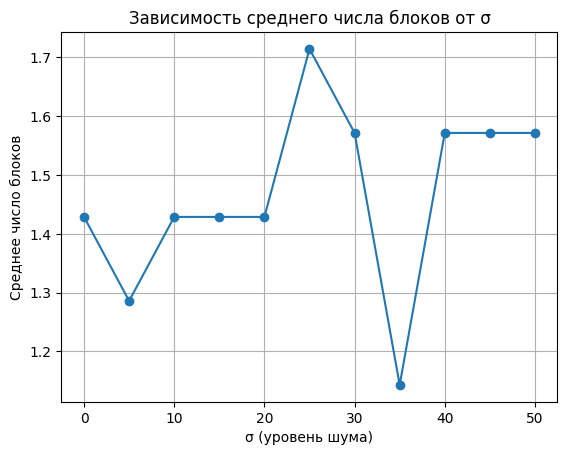

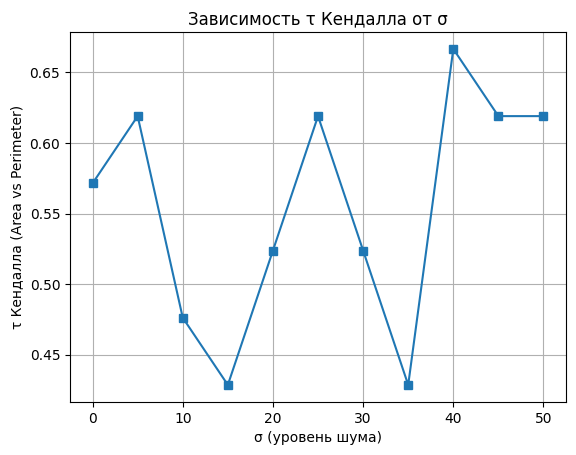

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Задаём диапазон шумов δ = σ
sigma_values = np.arange(0, 51, 5)  # от 0 до 50 с шагом 5

avg_connectivities = []
kendall_taus = []

for sigma in sigma_values:
    # (1) Обрабатываем эталонные буквы при уровне шума sigma
    ref_feats = process_reference_letters(ref_folder="ref_letters", sigma_noise=sigma)
    
    # (2) Среднее число блоков (connectivity) по всем буквам
    conn_vals = [f["connectivity"] for f in ref_feats.values()]
    avg_connectivities.append(np.mean(conn_vals))
    
    # (3) Коэффициент Кендалла τ между area и perimeter
    corr = compare_morph_features(ref_feats)
    kendall_taus.append(corr["tau_area_perimeter"])

# --- Рисуем график 1 ---
plt.figure()
plt.plot(sigma_values, avg_connectivities, marker='o')
plt.xlabel('σ (уровень шума)')
plt.ylabel('Среднее число блоков')
plt.title('Зависимость среднего числа блоков от σ')
plt.grid(True)

# --- Рисуем график 2 ---
plt.figure()
plt.plot(sigma_values, kendall_taus, marker='s')
plt.xlabel('σ (уровень шума)')
plt.ylabel('τ Кендалла (Area vs Perimeter)')
plt.title('Зависимость τ Кендалла от σ')
plt.grid(True)

plt.show()
